# Normal Distribution Check

In this Notebook we will see how can we check if our data is Normally distributed or not. Why do we care about Normal Distibution?

1) A lot of models assume data to be normal distributed <br>
2) PDF of normal distribution is known so we can get probabilities of every range. <br>
3) Approximately 68% value lies within 1 SD, 95% data lies within 2 SD and 99% data lie Within 3 SD. <br>
4) Mean = Median = Mode

In [1]:
#We Will first Import data
!pip install --upgrade pip
!pip install curl_cffi -U

from curl_cffi import requests
import datetime
import yfinance as yfin
import seaborn as sns
import numpy as np
import pandas as pd

session = requests.Session(impersonate="chrome")

# Starting and end dates
start = datetime.date(2004, 8, 1)
end = datetime.date(2024, 8, 1)

# Get the data
prices = pd.DataFrame(yfin.download(["^NSEI"], start, end, auto_adjust = False)["Adj Close"])

# Rename column to make names more intuitive
prices = prices.rename(columns={"^NSEI": "Nifty50"})

prices

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 98.3 MB/s eta 0:00:00
  Attempting uninstall: curl_cffi
    Found existing installation: curl_cffi 0.11.1
    Uninstalling curl_cffi-0.11.1:
      Successfully uninstalled curl_cffi-0.11.1


[*********************100%***********************]  1 of 1 completed


Ticker,Nifty50
Date,
2007-09-17,4494.649902
2007-09-18,4546.200195
2007-09-19,4732.350098
2007-09-20,4747.549805
2007-09-21,4837.549805
...,...
2024-07-25,24406.099609
2024-07-26,24834.849609
2024-07-29,24836.099609


Now we will convert the prices to Log Returns, We mostly try to work with log returns since they are additive in nature

In [2]:
df = np.log(prices['Nifty50']) - np.log(prices['Nifty50'].shift(1))
df = df.iloc[1:]
df = pd.DataFrame(df)
df

,Nifty50
Date,
2007-09-18,0.011404
2007-09-19,0.040130
2007-09-20,0.003207
2007-09-21,0.018780
2007-09-24,0.019377
...,...
2024-07-25,-0.000303
2024-07-26,0.017415
2024-07-29,0.000050


## Are the Returns Symmetric?

We will first now check whether the returns are symmetric or not, for that the mean = median = mode, should be Satisfied

In [3]:
mean = df.mean() *100 #just to show values in % terms
mode = df.mode() * 100
median = df.median() * 100
print('Mean (%)', mean)
print('Mode (%)', mode)
print('Median (%)', median)


Mean (%) Nifty50    0.041472
dtype: float64
Mode (%)    Nifty50
0      0.0
Median (%) Nifty50    0.073117
dtype: float64


So we can see above that mean median and mode are not equal, that means our data is not symmetric. Let's now see how many values in our dataset are greater than mean value.

In [4]:
(len(df[df['Nifty50'] >  df['Nifty50'].mean()]) / len(df['Nifty50']))

0.5129445923058311

From the Above data we can see that around 51.2% values are greater than nifty 50 mean values this means are data points are skewed a little towards Right

## Is Volatility Constant?

As we have seen in PDF of Normal Distribution the sigma was constant across time, so let's see whether the volatility of our returns are constant over time or not? To get Volatility over time we will take Rolling volatility

In [5]:
vol = pd.DataFrame(df['Nifty50'].rolling(50).std())
vol = vol.dropna()
vol = vol.rename(columns={'Nifty50': 'Volatility of Nifty 50'})
vol

,Volatility of Nifty 50
Date,
2007-11-28,0.020872
2007-11-29,0.020849
2007-11-30,0.020374
2007-12-03,0.020465
2007-12-04,0.020369
...,...
2024-07-25,0.012210
2024-07-26,0.012397
2024-07-29,0.012393


<Axes: xlabel='Date', ylabel='Volatility of Nifty 50'>

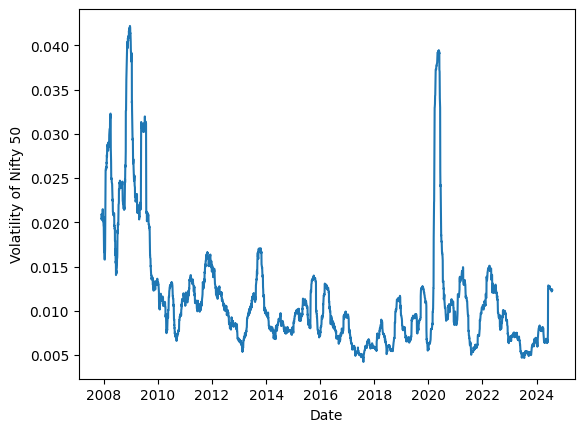

In [7]:
sns.lineplot(x = 'Date', y = 'Volatility of Nifty 50',data = vol)

As we can Clearly See from Above that volatility across time is not constant, this also violates the normality condition since in PDF for normal distribution the volatility remains constant

## Histogram

We will now see how histogram of our data looks like, generally histogram of normal data looks like bell curve

array([[<Axes: title={'center': 'Nifty50'}>]], dtype=object)

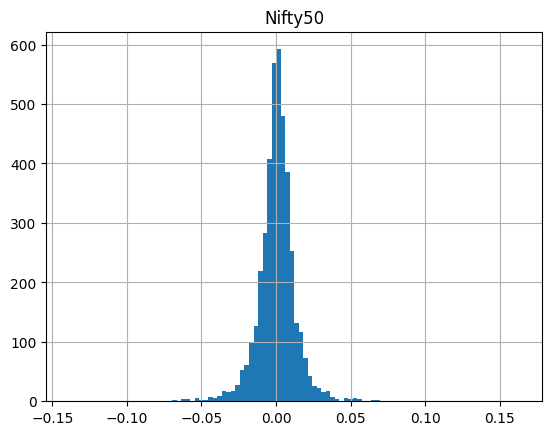

In [8]:
df.hist(bins =100)

The above data looks like bell shaped but we suspect it can be lepto kurtic

## D'Agostino & Pearson's Normality Test

In this Test H0: Data is normal and Ha: Data is not normal, our Test statistic is Z1^2 + Z2^2 where Z1 and Z2 are Z values of Skewness and excess Kurtosis (Kurtosis >3 ), so if Test stat is large this means our data has excess skewness and Kurtosis. Also if the P value < 0.05 this also means data is not normal ( Since p value represents area under tail and when it is very small the point usually lies in the rejection region )

In [10]:
!pip install stats

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'stats' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'stats'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for stats: filename=stats-0.1.2a0-py3-none-any.whl size=24283 sha256=be240fe5326f8fda8f032db724cd1ba0e802ae70483bf1a5daefe58923061aeb
  Stored in directory: /root/.cache/pip/wheels/57/7d/91/f1d0158783f74ab6ad725b00aa6a2c6e976cea652eb72616c6
Successfully built stats


In [18]:
from scipy import stats
stats.normaltest(np.array(df['Nifty50']))

NormaltestResult(statistic=np.float64(944.9833753447399), pvalue=np.float64(6.301838929671254e-206))

As we can see here that our test stat is very large and p value is very small (as it is something * 10^-206) therefore our data is not normal

## Jarque bera Test

Jarque Bera test also includes both Skewness and Kurtosis in it's test stat formula, and here also if p value <0.05 that means our data is not normal

In [19]:
stats.jarque_bera(np.array(df['Nifty50']))

SignificanceResult(statistic=np.float64(36873.13726670541), pvalue=np.float64(0.0))

Here also The p value is around 0, which means our data is again not normal

## QQ Plot

If the data is normal it should fall on the straight line

((array([-3.58630806, -3.34795351, -3.21642735, ...,  3.21642735,
          3.34795351,  3.58630806]),
  array([-0.13903756, -0.13014182, -0.09104607, ...,  0.06757428,
          0.08400295,  0.16334315])),
 (np.float64(0.012647017600903728),
  np.float64(0.0004147186426576708),
  np.float64(0.9420094322670554)))

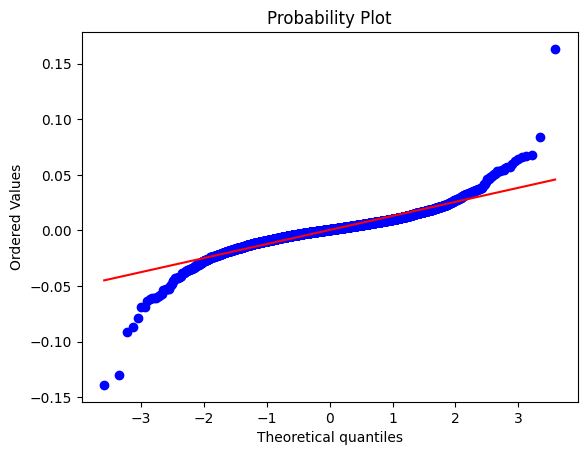

In [25]:
import matplotlib.pyplot as plt

stats.probplot(df['Nifty50'],dist = 'norm',plot = plt)

## Why is our Data Not Normal

Let's now try to check why is our data not normal

In [27]:
Z1 = ((df['Nifty50'].max() - df['Nifty50'].mean()) / df['Nifty50'].std())
Z2 = ((df['Nifty50'].min() - df['Nifty50'].mean()) / df['Nifty50'].std())
print('Maximum Value in terms of Z value is',Z1)
print('Minimum Value in terms of Z value is',Z2)

Maximum Value in terms of Z value is 12.143815901065892
Minimum Value in terms of Z value is -10.394028775088746


Here We can see that both maximum and Minimum values are very far than 3 SDs from mean

In [29]:
#number of points greater than 3 SD are
outliers = np.abs(df['Nifty50'] - df['Nifty50'].mean()) > (3* df['Nifty50'].std())
num_outliers = outliers.sum()
num_outliers

np.int64(68)

There are total 68 outliers that represents around 1.6% of the data, ideally only 0.3% data should be > 3 SD

<Axes: ylabel='Density'>

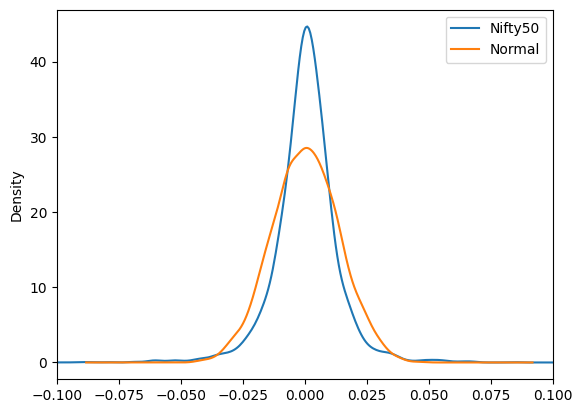

In [35]:
#Let's compare our data as compared to the normal distribution
norm_data = stats.norm.rvs(size=len(df['Nifty50']), loc = df["Nifty50"].mean(), scale = df["Nifty50"].std())
df['Normal'] = norm_data
df[['Nifty50','Normal']].plot(kind = 'kde',xlim = (-0.1,0.1) )

As we can see our data has very long tails as compared to the normal distribution and it has a very long peak as well, our data looks like lepto kurtic. The tails of our data are not fat as compared to the normal data though we just have long tails. Fat tails means probability of point at tails is more